In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier #C.MC ARBOL DE DESICIONES
from sklearn.neighbors import KNeighborsClassifier #C.ML VECINOS CERCANOS

In [ ]:
mnist = fetch_openml("Fashion-MNIST", version =1, as_frame = False)

In [ ]:
x = mnist.data/255.0 #OBTENEMOS LOS DATOS  Y LOS NORMALIZAMOS
y = mnist.target

In [ ]:
mnist.data.shape

(70000, 784)

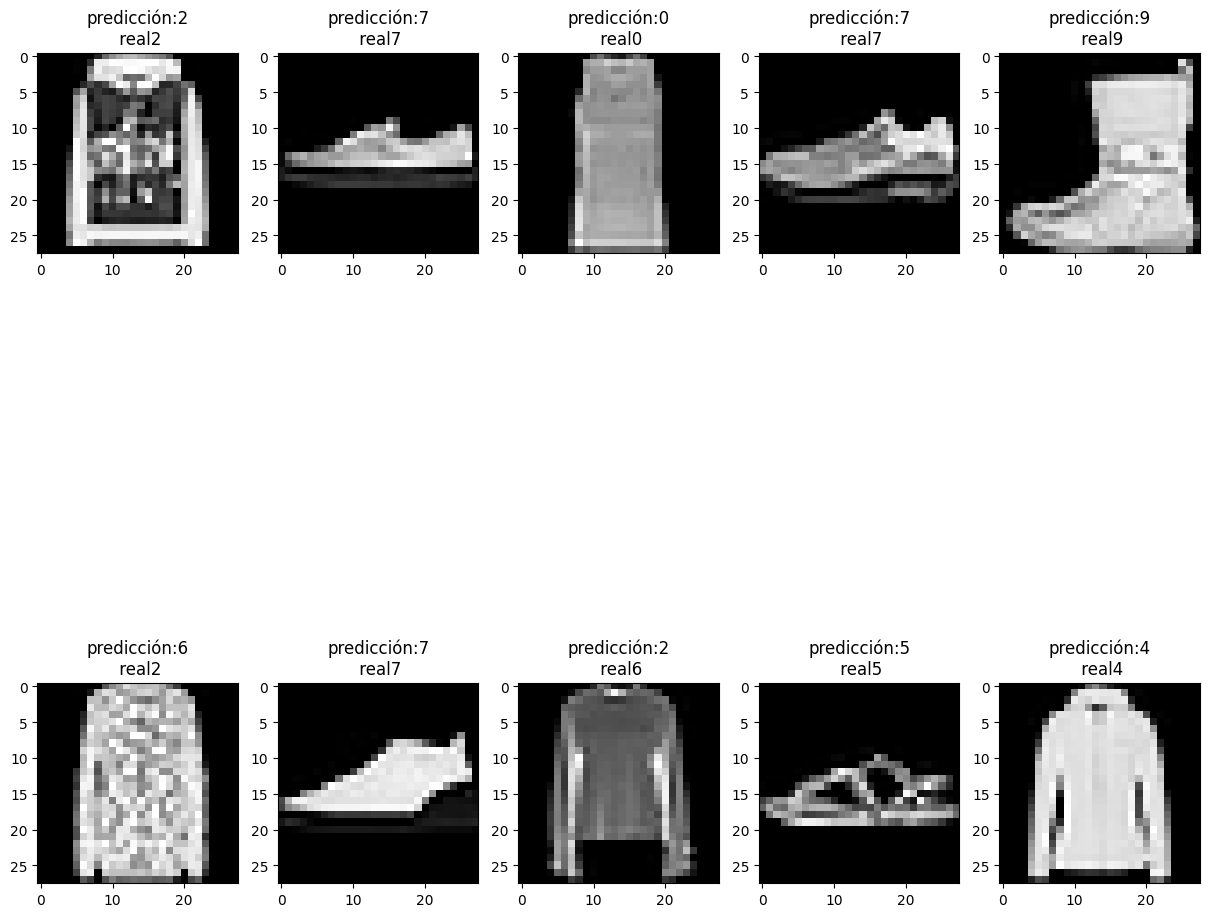

In [ ]:
plt.figure(figsize=(15,15))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap= "gray")
    plt.title("predicción:"+ y_pred[i] + "\n real"+ y_test[i])

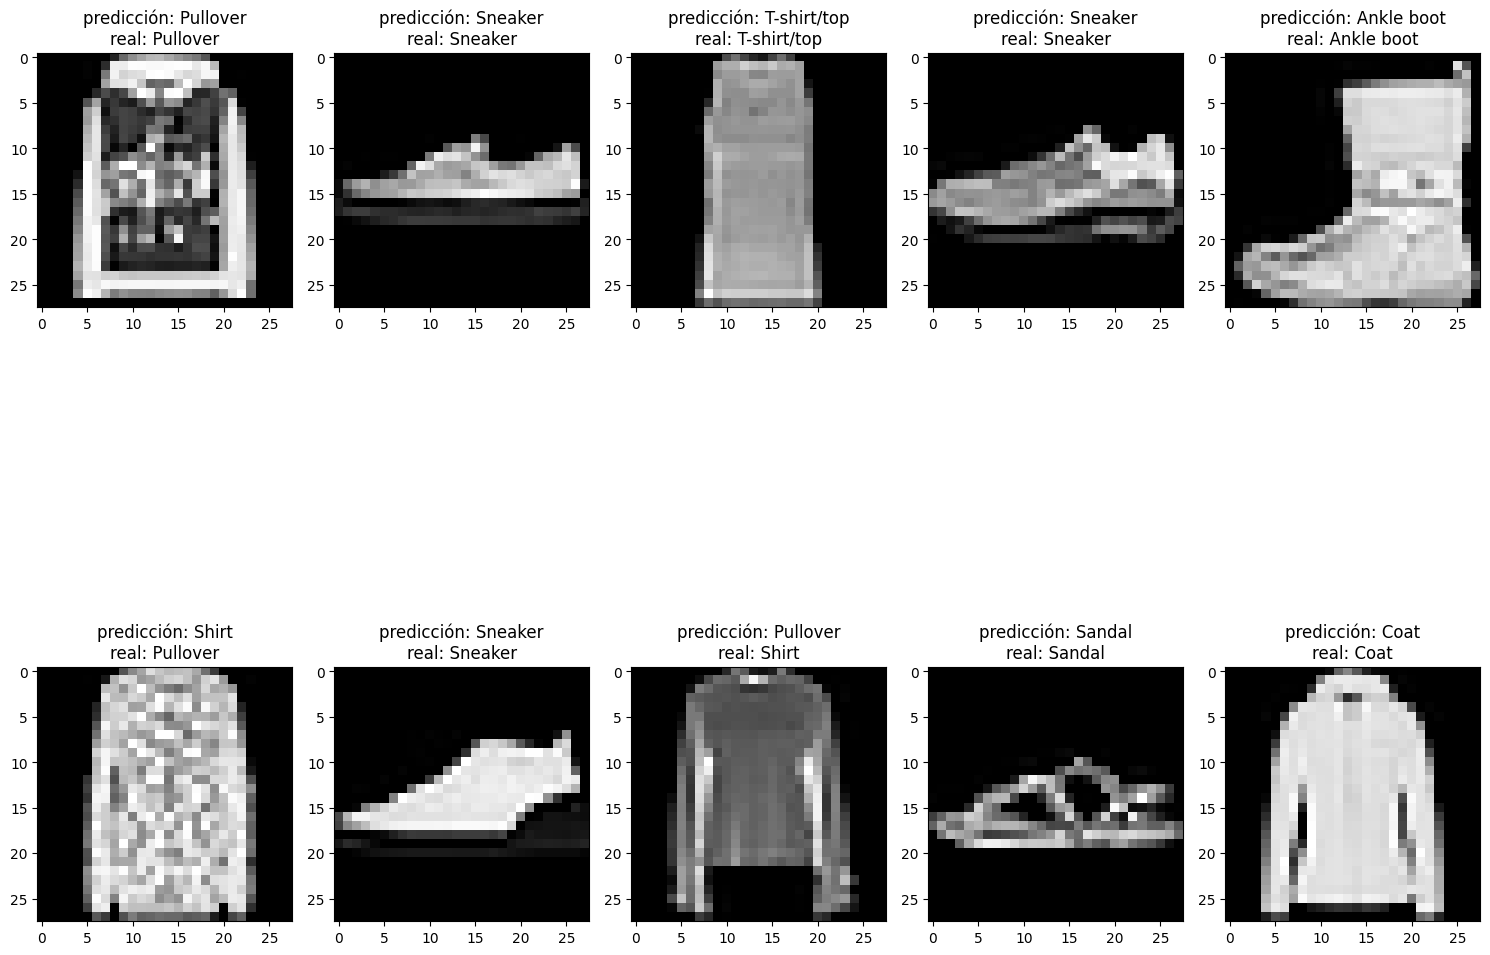

In [ ]:
# Lista oficial de clases de Fashion-MNIST
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(15, 15))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    # Usamos los índices para obtener el nombre textual
    pred_label = class_names[int(y_pred[i])]
    real_label = class_names[int(y_test[i])]

    plt.title(f"predicción: {pred_label}\nreal: {real_label}")

plt.tight_layout()
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

## DECISIONTREECLASSIFIER

In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_DTC = model.predict(x_test)
print("Predicciones del modelo")
print(y_pred_DTC)
print("Etiquetas reales")
print(y_test)

Predicciones del modelo
['4' '7' '0' ... '9' '0' '7']
Etiquetas reales
['2' '7' '0' ... '9' '0' '7']


In [ ]:
#Precisión del modelo Decision TreeClasifier
print(accuracy_score(y_test, y_pred_DTC))
print(classification_report(y_test, y_pred_DTC))

0.7921428571428571
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1394
           1       0.94      0.95      0.95      1402
           2       0.67      0.68      0.68      1407
           3       0.82      0.78      0.80      1449
           4       0.65      0.67      0.66      1357
           5       0.89      0.89      0.89      1449
           6       0.53      0.52      0.53      1407
           7       0.87      0.88      0.88      1359
           8       0.91      0.90      0.91      1342
           9       0.90      0.90      0.90      1434

    accuracy                           0.79     14000
   macro avg       0.79      0.79      0.79     14000
weighted avg       0.79      0.79      0.79     14000



In [ ]:
idx = 0
muestra = x_test[idx]
#muestra
pred = model.predict(muestra.reshape(1,-1))
pred

array(['2'], dtype=object)

Text(0.5, 1.0, "['2']")

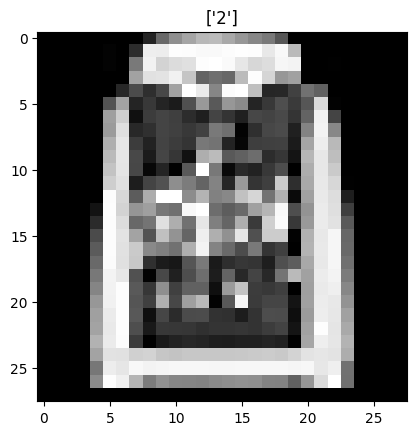

In [ ]:
plt.imshow(muestra.reshape(28,28), cmap = "gray")
plt.title(pred)

## KNEIGHBORSCLASSIFIER



In [ ]:
model = KNeighborsClassifier()
model.fit(x_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_KN = model.predict(x_test)
print("Predicciones del modelo")
print(y_pred_KN)
print("Etiquetas reales")
print(y_test)

Predicciones del modelo
['2' '7' '0' ... '9' '0' '7']
Etiquetas reales
['2' '7' '0' ... '9' '0' '7']


In [ ]:
#Precisión del modelo con KNeighborsClassifier
print(accuracy_score(y_test, y_pred_KN))
print(classification_report(y_test, y_pred_KN))

0.8567857142857143
              precision    recall  f1-score   support

           0       0.77      0.87      0.82      1394
           1       0.99      0.97      0.98      1402
           2       0.73      0.80      0.76      1407
           3       0.91      0.86      0.89      1449
           4       0.77      0.77      0.77      1357
           5       1.00      0.84      0.91      1449
           6       0.68      0.58      0.63      1407
           7       0.87      0.96      0.91      1359
           8       0.98      0.95      0.96      1342
           9       0.90      0.96      0.93      1434

    accuracy                           0.86     14000
   macro avg       0.86      0.86      0.86     14000
weighted avg       0.86      0.86      0.86     14000



##Comparativa

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# 1. Métrica global
acc_kn = accuracy_score(y_test, y_pred_KN)
acc_dtc = accuracy_score(y_test, y_pred_DTC)

print(f"Accuracy KNN: {acc_kn:.4f}")
print(f"Accuracy Decision Tree: {acc_dtc:.4f}")
print(f"Diferencia a favor de KNN: {acc_kn - acc_dtc:.4f}\n")

# 2. Generar diccionarios de reportes
rep_kn = classification_report(y_test, y_pred_KN, output_dict=True)
rep_dtc = classification_report(y_test, y_pred_DTC, output_dict=True)

# 3. Armar DataFrame por clase
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

df_comp = pd.DataFrame({
    'KNN (F1)': [rep_kn[str(i)]['f1-score'] for i in range(10)],
    'Árbol (F1)': [rep_dtc[str(i)]['f1-score'] for i in range(10)]
}, index=class_names)

# Ventaja de KNN por prenda
df_comp['Ventaja KNN'] = df_comp['KNN (F1)'] - df_comp['Árbol (F1)']

df_comp

Accuracy KNN: 0.8568
Accuracy Decision Tree: 0.7921
Diferencia a favor de KNN: 0.0646



,KNN (F1),Árbol (F1),Ventaja KNN
T-shirt/top,0.817602,0.739814,0.077787
Trouser,0.981635,0.945764,0.035871
Pullover,0.762580,0.675647,0.086933
Dress,0.885745,0.798307,0.087437
Coat,0.771839,0.657495,0.114345
Sandal,0.910252,0.894337,0.015915
Shirt,0.626193,0.525902,0.100291
Sneaker,0.913684,0.875092,0.038592
Bag,0.962179,0.907387,0.054792
Ankle boot,0.930280,0.900625,0.029654
